# cVAE Post-Training Analysis for AMP Generation

The notebook for post-training analysis of the conditional VAE.

Goals:
- load the trained cVAE and saved vocabulary
- evaluate reconstruction and generation quality
- analyze latent space with t-SNE
- compare real and generated peptides
- inspect interpolation trajectories
- compute physicochemical properties of peptides


In [1]:
import os
import math
import json
import random
import pickle
from pathlib import Path

import umap
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from tqdm.auto import tqdm, trange


C:\Users\artem\Study\explainable-VAE-for-AMP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ------------------------------------------------------------------
# Paths and reproducibility
# ------------------------------------------------------------------
ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(os.getcwd()).parent
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "docs" / "figures"
TABLES_DIR = ROOT / "docs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("device:", device)


ROOT: C:\Users\artem\Study\explainable-VAE-for-AMP
DATA_DIR: C:\Users\artem\Study\explainable-VAE-for-AMP\data
MODELS_DIR: C:\Users\artem\Study\explainable-VAE-for-AMP\models
FIGURES_DIR: C:\Users\artem\Study\explainable-VAE-for-AMP\docs\figures
TABLES_DIR: C:\Users\artem\Study\explainable-VAE-for-AMP\docs\tables
device: cpu


## 1. Load dataset and saved artifacts

Expected files:
- `data/preprocessed/data.csv`
- `models/best_cvae.pt`
- `models/vocab.pkl`
- optional: `models/cvae_history.csv`


In [4]:
DATA_PATH = DATA_DIR / "preprocessed" / "data.csv"
VOCAB_PATH = MODELS_DIR / "vocab.pkl"
MODEL_PATH = MODELS_DIR / "best_cvae.pt"
HISTORY_PATH = MODELS_DIR / "cvae_history.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATA_PATH}")
if not VOCAB_PATH.exists():
    raise FileNotFoundError(f"Missing vocabulary: {VOCAB_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing model checkpoint: {MODEL_PATH}")

df = pd.read_csv(DATA_PATH)

with open(VOCAB_PATH, "rb") as f:
    vocab_data = pickle.load(f)

char2idx = vocab_data["char2idx"]
idx2char = vocab_data["idx2char"]
max_len = vocab_data["max_len"]
vocab_list = vocab_data["vocab_list"]
condition_cols = vocab_data["condition_cols"]

PAD_IDX = char2idx["<PAD>"]
SOS_IDX = char2idx["<SOS>"]
EOS_IDX = char2idx["<EOS>"]
UNK_IDX = char2idx["<UNK>"]

seq_col = "Sequence"
len_col = "Length"
vocab_size = len(vocab_list)

keep_cols = ["APD ID", seq_col, len_col] + condition_cols
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].dropna(subset=[seq_col]).copy()

for col in condition_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

print("dataset shape:", df.shape)
print("vocab size:", vocab_size)
print("max_len:", max_len)
print("condition cols:", condition_cols)
df.head()


dataset shape: (5984, 10)
vocab size: 24
max_len: 64
condition cols: ['is_antibacterial', 'is_anti_gram_positive', 'is_anti_gram_negative', 'is_antifungal', 'is_antiviral', 'is_antiparasitic', 'is_anticancer']


,APD ID,Sequence,Length,is_antibacterial,is_anti_gram_positive,is_anti_gram_negative,is_antifungal,is_antiviral,is_antiparasitic,is_anticancer
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,33,1,1,1,1,0,1,1
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,34,1,1,1,0,0,0,0
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,54,0,0,0,1,0,0,0
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,49,1,1,0,1,0,0,0
4,AP00005,VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK,34,1,1,0,0,0,0,0


In [5]:
def tokenize(seq, char2idx, max_len, add_sos_eos=True):
    tokens = [char2idx.get(ch, UNK_IDX) for ch in seq]
    if add_sos_eos:
        tokens = [SOS_IDX] + tokens + [EOS_IDX]
    if len(tokens) < max_len:
        tokens += [PAD_IDX] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

def detokenize(tokens):
    chars = []
    for idx in tokens:
        if idx in [PAD_IDX, SOS_IDX]:
            continue
        if idx == EOS_IDX:
            break
        chars.append(idx2char.get(int(idx), ""))
    return "".join(chars)

tokenized_seqs = [tokenize(seq, char2idx, max_len) for seq in df[seq_col]]
real_lengths = np.array([min(len(seq) + 2, max_len) for seq in df[seq_col]])
conditions = df[condition_cols].values.astype(np.float32)

all_chars = sorted([x for x in char2idx.keys() if len(x) == 1])
valid_amino_acids = set(all_chars)

print("amino acids:", all_chars)
print("num sequences:", len(tokenized_seqs))


amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
num sequences: 5984


In [6]:
class AMPDataset(Dataset):
    def __init__(self, sequences, lengths, conditions):
        self.sequences = torch.LongTensor(sequences)
        self.lengths = torch.LongTensor(lengths)
        self.conditions = torch.FloatTensor(conditions)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.conditions[idx]

dataset = AMPDataset(tokenized_seqs, real_lengths, conditions)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))


train/val/test: 4787 598 599


## 2. Rebuild the exact cVAE architecture and load weights


In [7]:
# ------------------------------------------------------------------
# Hyperparameters used in training notebook
# ------------------------------------------------------------------
embed_dim = 128
enc_hidden_dim = 1024
dec_hidden_dim = 512
latent_dim = 32
cond_dim = len(condition_cols)
num_layers = 1
dropout = 0.2


In [8]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim + cond_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_dim, latent_dim)

    def forward(self, x, lengths, cond):
        embedded = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        hidden = h_n[-1]
        hidden_cond = torch.cat([hidden, cond], dim=1)
        return self.fc_mu(hidden_cond), self.fc_logvar(hidden_cond)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim + latent_dim + cond_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.init_h = nn.Linear(latent_dim + cond_dim, hidden_dim)
        self.init_c = nn.Linear(latent_dim + cond_dim, hidden_dim)

    def forward(self, x, z, cond, word_dropout_rate=0.0):
        batch_size, seq_len = x.shape
        z_cond = torch.cat([z, cond], dim=1)
        h0 = torch.tanh(self.init_h(z_cond)).unsqueeze(0)
        c0 = torch.tanh(self.init_c(z_cond)).unsqueeze(0)

        embedded = self.drop(self.embedding(x))
        z_expand = z.unsqueeze(1).expand(-1, seq_len, -1)
        cond_expand = cond.unsqueeze(1).expand(-1, seq_len, -1)
        lstm_input = torch.cat([embedded, z_expand, cond_expand], dim=2)

        outputs, _ = self.lstm(lstm_input, (h0, c0))
        return self.fc_out(outputs)


class CVAE(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden, latent_dim, cond_dim, dropout)
        self.decoder = Decoder(vocab_size, embed_dim, dec_hidden, latent_dim, cond_dim, dropout)
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, src, lengths, cond, word_dropout_rate=0.0):
        mu, logvar = self.encoder(src, lengths, cond)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(src[:, :-1], z, cond, word_dropout_rate)
        return logits, src[:, 1:], mu, logvar


In [9]:
model = CVAE(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    enc_hidden=enc_hidden_dim,
    dec_hidden=dec_hidden_dim,
    latent_dim=latent_dim,
    cond_dim=cond_dim,
    dropout=dropout,
).to(device)

try:
    state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(state_dict)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print("Loaded model from:", MODEL_PATH)
print("Parameters:", f"{n_params:,}")


Loaded model from: C:\Users\artem\Study\explainable-VAE-for-AMP\models\best_cvae.pt
Parameters: 6,246,936


## 3. Optional: plot training history


In [10]:
if HISTORY_PATH.exists():
    hist = pd.read_csv(HISTORY_PATH)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(hist["train_loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(hist["recon"])
    axes[1].set_title("Reconstruction term")

    axes[2].plot(hist["kl"])
    axes[2].set_title("KL term")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cvae_training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Training history file not found. Skip this section.")


Training history file not found. Skip this section.


## 4. Generation and reconstruction utilities


In [11]:
def _decode_from_z_cond(model, z, cond_t, max_gen_len, temperature=1.0, greedy=False):
    z_cond = torch.cat([z, cond_t], dim=1)
    h = torch.tanh(model.decoder.init_h(z_cond)).unsqueeze(0)
    c = torch.tanh(model.decoder.init_c(z_cond)).unsqueeze(0)

    input_token = torch.LongTensor([[SOS_IDX]]).to(device)
    generated = []

    for _ in range(max_gen_len):
        embedded = model.decoder.embedding(input_token)
        lstm_input = torch.cat([embedded, z.unsqueeze(1), cond_t.unsqueeze(1)], dim=2)
        output, (h, c) = model.decoder.lstm(lstm_input, (h, c))
        logits = model.decoder.fc_out(output.squeeze(1))

        if greedy:
            next_token = logits.argmax(dim=-1).item()
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1).item()

        if next_token == EOS_IDX:
            break

        generated.append(next_token)
        input_token = torch.LongTensor([[next_token]]).to(device)

    return detokenize(generated)


def generate(model, cond, max_gen_len=None, temperature=0.8, alpha=1.0, greedy=False):
    if max_gen_len is None:
        max_gen_len = max_len - 2

    model.eval()
    with torch.no_grad():
        cond_t = torch.FloatTensor(cond).unsqueeze(0).to(device) * alpha
        z = torch.randn(1, latent_dim).to(device)
        return _decode_from_z_cond(model, z, cond_t, max_gen_len, temperature=temperature, greedy=greedy)


def reconstruct_sequence(model, seq, cond):
    tokens = torch.LongTensor([tokenize(seq, char2idx, max_len)]).to(device)
    lengths = torch.LongTensor([min(len(seq) + 2, max_len)]).to(device)
    cond_t = torch.FloatTensor([cond]).to(device)

    model.eval()
    with torch.no_grad():
        mu, _ = model.encoder(tokens, lengths, cond_t)
        recon = _decode_from_z_cond(model, mu, cond_t, max_len - 2, temperature=1.0, greedy=True)
    return recon


In [12]:
# quick smoke test
cond_gp = [0, 1, 0, 0, 0, 0, 0]
for i in range(3):
    print(generate(model, cond_gp))


KRRRGRLAYLARRLRPPLKR
FLPFLAGLLTKLL
FFPLLAGLLGKLL


## 5. Quantitative evaluation


In [13]:
def batch_reconstruction_metrics(model, loader):
    exact_matches = 0
    total = 0
    token_matches = 0
    token_total = 0

    model.eval()
    with torch.no_grad():
        for src, lengths, cond in tqdm(loader, desc="Reconstruction eval"):
            src = src.to(device)
            lengths = lengths.to(device)
            cond = cond.to(device)

            mu, _ = model.encoder(src, lengths, cond)
            logits = model.decoder(src[:, :-1], mu, cond, word_dropout_rate=0.0)
            pred = logits.argmax(dim=-1)
            target = src[:, 1:]

            mask = target != PAD_IDX
            token_matches += (pred[mask] == target[mask]).sum().item()
            token_total += mask.sum().item()

            for i in range(src.size(0)):
                gold = detokenize(target[i].detach().cpu().numpy())
                rec = detokenize(pred[i].detach().cpu().numpy())
                exact_matches += int(gold == rec)
                total += 1

    return {
        "exact_reconstruction_accuracy": exact_matches / max(total, 1),
        "token_accuracy": token_matches / max(token_total, 1),
        "n_sequences": total,
    }

recon_metrics = batch_reconstruction_metrics(model, test_loader)
recon_metrics


Reconstruction eval: 100%|██████████| 3/3 [00:02<00:00,  1.10it/s]


{'exact_reconstruction_accuracy': 0.0,
 'token_accuracy': 0.5488149744142203,
 'n_sequences': 599}

In [14]:
def evaluate_generation(model, cond, num_samples=200, train_seqs_set=None, alpha=1.0, temperature=0.8):
    generated = [generate(model, cond, temperature=temperature, alpha=alpha) for _ in range(num_samples)]
    valid = [s for s in generated if len(s) > 0 and all(ch in valid_amino_acids for ch in s)]

    validity = len(valid) / num_samples
    unique_valid = set(valid)
    uniqueness = len(unique_valid) / max(len(valid), 1)

    novelty = None
    if train_seqs_set is not None:
        novelty = len([s for s in unique_valid if s not in train_seqs_set]) / max(len(unique_valid), 1)

    avg_len = np.mean([len(s) for s in valid]) if valid else 0.0

    return {
        "validity": validity,
        "uniqueness": uniqueness,
        "novelty": novelty,
        "avg_length": avg_len,
        "valid_sequences": valid,
    }

train_seqs_set = set(df.iloc[train_dataset.indices][seq_col].tolist())

conditions_to_test = {
    "Antibacterial": [1, 0, 0, 0, 0, 0, 0],
    "Gram+":         [0, 1, 0, 0, 0, 0, 0],
    "Gram-":         [0, 0, 1, 0, 0, 0, 0],
    "Antifungal":    [0, 0, 0, 1, 0, 0, 0],
    "Antiviral":     [0, 0, 0, 0, 1, 0, 0],
    "Anticancer":    [0, 0, 0, 0, 0, 0, 1],
    "Unconditional": [0, 0, 0, 0, 0, 0, 0],
}

rows = []
generated_cache = {}

for name, cond in tqdm(conditions_to_test.items(), desc="Generation eval"):
    out = evaluate_generation(model, cond, num_samples=250, train_seqs_set=train_seqs_set)
    generated_cache[name] = out["valid_sequences"]
    rows.append({
        "condition": name,
        "validity": out["validity"],
        "uniqueness": out["uniqueness"],
        "novelty": out["novelty"],
        "avg_length": out["avg_length"],
        "n_valid": len(out["valid_sequences"]),
    })

metrics_df = pd.DataFrame(rows).sort_values("condition").reset_index(drop=True)
metrics_df.to_csv(TABLES_DIR / "generation_metrics.csv", index=False)
metrics_df


Generation eval: 100%|██████████| 7/7 [01:45<00:00, 15.05s/it]


,condition,validity,uniqueness,novelty,avg_length,n_valid
0,Antibacterial,1.000,1.000000,0.952000,29.124000,250
1,Anticancer,0.996,0.879518,0.954338,30.751004,249
2,Antifungal,1.000,0.916000,0.965066,33.020000,250
3,Antiviral,1.000,0.932000,0.914163,25.788000,250
4,Gram+,1.000,0.948000,0.940928,26.368000,250
5,Gram-,1.000,0.804000,0.800995,23.912000,250
6,Unconditional,1.000,0.960000,0.941667,27.896000,250


## 6. Physicochemical properties

We compute:
- length
- net charge
- APD-style hydrophobic ratio
- mean hydrophobicity (Kyte-Doolittle)
- hydrophobic moment


In [15]:
KD_SCALE = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3,
}

CHARGE_MAP = {"K": 1, "R": 1, "H": 0.5, "D": -1, "E": -1}
APD_HYDROPHOBIC = set(["I", "V", "L", "F", "C", "M", "A", "W"])

def net_charge(seq):
    return sum(CHARGE_MAP.get(aa, 0) for aa in seq)

def kd_hydrophobicity(seq):
    if len(seq) == 0:
        return 0.0
    return float(np.mean([KD_SCALE.get(aa, 0.0) for aa in seq]))

def hydrophobic_ratio_apd(seq):
    if len(seq) == 0:
        return 0.0
    return sum(aa in APD_HYDROPHOBIC for aa in seq) / len(seq)

def hydrophobic_moment(seq, angle=100):
    if len(seq) == 0:
        return 0.0
    delta = math.radians(angle)
    sin_sum = sum(KD_SCALE.get(aa, 0.0) * math.sin(i * delta) for i, aa in enumerate(seq))
    cos_sum = sum(KD_SCALE.get(aa, 0.0) * math.cos(i * delta) for i, aa in enumerate(seq))
    return math.sqrt(sin_sum ** 2 + cos_sum ** 2) / len(seq)

def compute_properties(sequences, source_name="unknown"):
    rows = []
    for seq in sequences:
        rows.append({
            "sequence": seq,
            "source": source_name,
            "length": len(seq),
            "net_charge": net_charge(seq),
            "hydrophobic_ratio_apd": hydrophobic_ratio_apd(seq),
            "kd_hydrophobicity": kd_hydrophobicity(seq),
            "hydrophobic_moment": hydrophobic_moment(seq),
        })
    return pd.DataFrame(rows)


In [16]:
real_prop_frames = []
for name, col in {
    "Gram+": "is_anti_gram_positive",
    "Gram-": "is_anti_gram_negative",
    "Antifungal": "is_antifungal",
    "Anticancer": "is_anticancer",
}.items():
    if col in df.columns:
        seqs = df.loc[df[col] == 1, seq_col].tolist()
        tmp = compute_properties(seqs, source_name=f"real::{name}")
        tmp["condition"] = name
        tmp["kind"] = "real"
        real_prop_frames.append(tmp)

real_props = pd.concat(real_prop_frames, ignore_index=True)

gen_prop_frames = []
for name, seqs in generated_cache.items():
    tmp = compute_properties(seqs, source_name=f"generated::{name}")
    tmp["condition"] = name
    tmp["kind"] = "generated"
    gen_prop_frames.append(tmp)

gen_props = pd.concat(gen_prop_frames, ignore_index=True)

all_props = pd.concat([real_props, gen_props], ignore_index=True)
all_props.to_csv(TABLES_DIR / "peptide_properties.csv", index=False)

all_props.head()


,sequence,source,length,net_charge,hydrophobic_ratio_apd,kd_hydrophobicity,hydrophobic_moment,condition,kind
0,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,real::Gram+,33,3.0,0.545455,0.196970,0.736514,Gram+,real
1,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,real::Gram+,34,4.0,0.235294,-0.911765,0.419809,Gram+,real
2,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,real::Gram+,49,3.5,0.367347,-0.848980,0.246959,Gram+,real
3,VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK,real::Gram+,34,0.5,0.500000,0.220588,1.562643,Gram+,real
4,GNNRPVYIPQPRPPHPRI,real::Gram+,18,3.5,0.166667,-1.405556,0.279268,Gram+,real


In [17]:
summary_props = (
    all_props.groupby(["kind", "condition"])[
        ["length", "net_charge", "hydrophobic_ratio_apd", "kd_hydrophobicity", "hydrophobic_moment"]
    ]
    .agg(["mean", "std"])
)

summary_props


length            net_charge            \
                              mean        std       mean       std   
kind      condition                                                  
generated Antibacterial  29.124000  12.308151   3.966000  3.428829   
          Anticancer     30.751004   5.746164   1.317269  1.924938   
          Antifungal     33.020000  14.753245   4.782000  2.902961   
          Antiviral      25.788000   8.388116   2.732000  3.109478   
          Gram+          26.368000  12.185669   2.972000  2.823314   
          Gram-          23.912000  11.167592   5.580000  3.394657   
          Unconditional  27.896000   8.879220   2.048000  2.649486   
real      Anticancer     24.286604   9.362097   3.171340  2.720625   
          Antifungal     24.670085  11.492896   4.251282  2.689530   
          Gram+          24.115694  11.389705   4.304613  3.035449   
          Gram-          22.905532  10.744060   4.676417  2.914881   

                        hydrophobic_ratio_apd           kd_hydrophobicity  \
                                         mean       std              mean   
kind      condition                                                         
generated Antibacterial              0.423076  0.151784         -0.065924   
          Anticancer                 0.427309  0.070986          0.318585   
          Antifungal                 0.370760  0.149815         -0.627840   
          Antiviral                  0.450333  0.098640          0.181678   
          Gram+                      0.493727  0.139726          0.512768   
          Gram-                      0.339424  0.152236         -0.779807   
          Unconditional              0.472145  0.113973          0.355118   
real      Anticancer                 0.496574  0.119868          0.420918   
          Antifungal                 0.441435  0.141780         -0.125432   
          Gram+                      0.464188  0.133174         -0.003481   
          Gram-                      0.438366  0.140034         -0.219945   

                                  hydrophobic_moment            
                              std               mean       std  
kind      condition                                             
generated Antibacterial  0.968712           0.852334  0.596582  
          Anticancer     0.454738           0.354233  0.362203  
          Antifungal     0.943657           0.646093  0.450016  
          Antiviral      0.717930           0.892087  0.727161  
          Gram+          1.010399           0.948093  0.620076  
          Gram-          1.103804           1.104831  0.605915  
          Unconditional  0.745979           0.748787  0.578647  
real      Anticancer     0.822071           1.076009  0.602940  
          Antifungal     0.977624           1.000177  0.627098  
          Gram+          0.985494           1.005597  0.602430  
          Gram-          0.997201           1.084716  0.635886

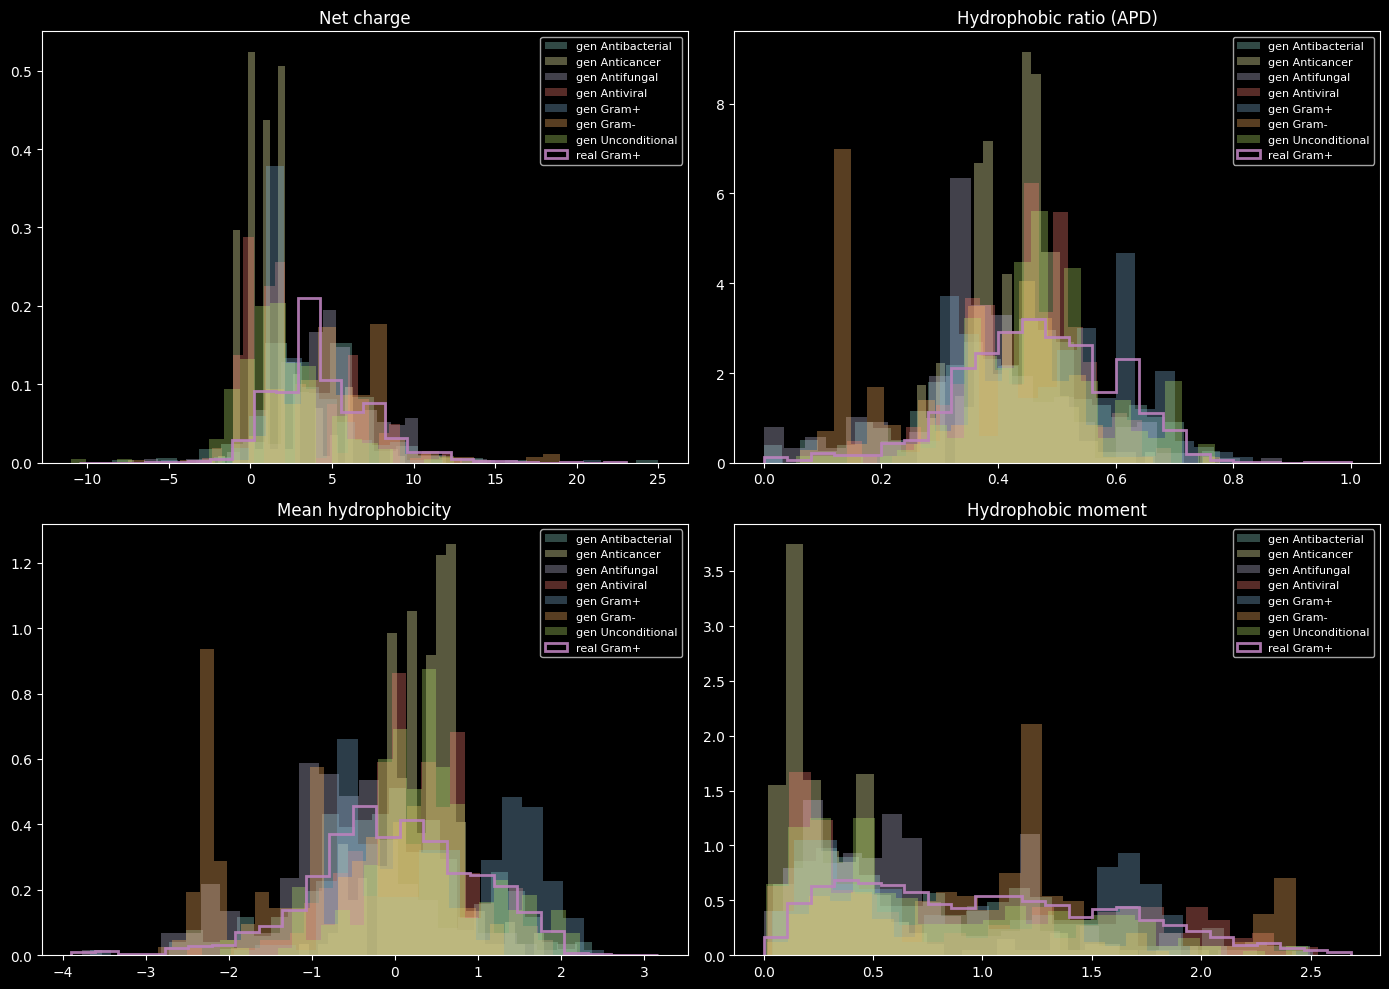

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    ("net_charge", "Net charge"),
    ("hydrophobic_ratio_apd", "Hydrophobic ratio (APD)"),
    ("kd_hydrophobicity", "Mean hydrophobicity"),
    ("hydrophobic_moment", "Hydrophobic moment"),
]

for ax, (col, title) in zip(axes.flat, plot_specs):
    for cond in sorted(gen_props["condition"].unique()):
        vals = gen_props.loc[gen_props["condition"] == cond, col]
        ax.hist(vals, bins=25, alpha=0.35, density=True, label=f"gen {cond}")

    real_ref = real_props.loc[real_props["condition"] == "Gram+", col]
    if len(real_ref) > 0:
        ax.hist(real_ref, bins=25, alpha=0.9, density=True, histtype="step", linewidth=2, label="real Gram+")

    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "physchem_distributions.png", dpi=220, bbox_inches="tight")
plt.show()


## 7. Latent space extraction


In [19]:
def get_latent_vectors(model, loader):
    model.eval()
    latents = []
    conds = []
    with torch.no_grad():
        for src, lengths, cond in tqdm(loader, desc="Extracting latents"):
            src = src.to(device)
            lengths = lengths.to(device)
            cond = cond.to(device)
            mu, _ = model.encoder(src, lengths, cond)
            latents.append(mu.cpu().numpy())
            conds.append(cond.cpu().numpy())
    return np.concatenate(latents), np.concatenate(conds)

full_loader = DataLoader(dataset, batch_size=256, shuffle=False)
real_latents, real_conds = get_latent_vectors(model, full_loader)

print("real_latents:", real_latents.shape)
print("real_conds:", real_conds.shape)


Extracting latents: 100%|██████████| 24/24 [00:21<00:00,  1.14it/s]

real_latents: (5984, 32)
real_conds: (5984, 7)


In [20]:
TSNE_REAL_SUBSAMPLE = min(3000, len(real_latents))
real_idx = np.random.choice(len(real_latents), size=TSNE_REAL_SUBSAMPLE, replace=False)

real_latents_sub = real_latents[real_idx]
real_conds_sub = real_conds[real_idx]
real_df_sub = df.iloc[real_idx].reset_index(drop=True)

print("t-SNE real subset:", real_latents_sub.shape)


t-SNE real subset: (3000, 32)


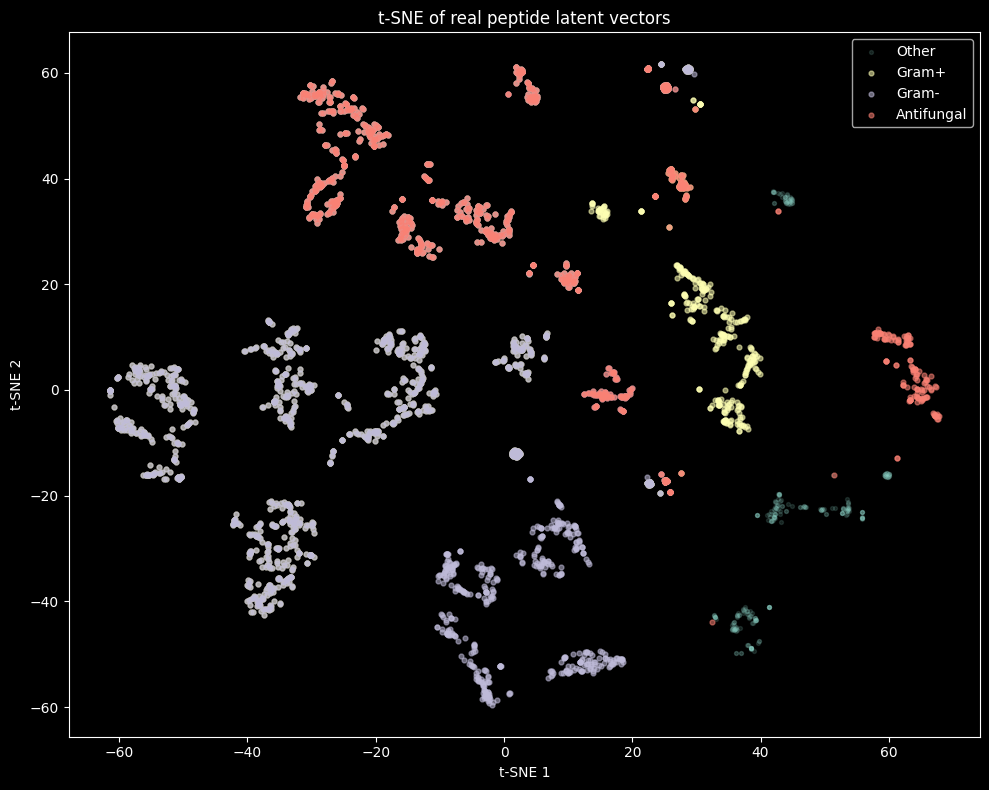

In [21]:
tsne_real = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)
real_2d = tsne_real.fit_transform(real_latents_sub)

fig, ax = plt.subplots(figsize=(10, 8))

gram_pos_idx = real_conds_sub[:, 1] == 1
gram_neg_idx = real_conds_sub[:, 2] == 1
antifungal_idx = real_conds_sub[:, 3] == 1
other_idx = ~(gram_pos_idx | gram_neg_idx | antifungal_idx)

ax.scatter(real_2d[other_idx, 0], real_2d[other_idx, 1], s=8, alpha=0.15, label="Other")
ax.scatter(real_2d[gram_pos_idx, 0], real_2d[gram_pos_idx, 1], s=12, alpha=0.55, label="Gram+")
ax.scatter(real_2d[gram_neg_idx, 0], real_2d[gram_neg_idx, 1], s=12, alpha=0.55, label="Gram-")
ax.scatter(real_2d[antifungal_idx, 0], real_2d[antifungal_idx, 1], s=12, alpha=0.55, label="Antifungal")

ax.set_title("t-SNE of real peptide latent vectors")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_real_latents.png", dpi=220, bbox_inches="tight")
plt.show()


## 8. Real vs generated comparison in latent space


In [22]:
def encode_sequences_with_condition(model, sequences, cond_vector):
    tokens = [tokenize(s, char2idx, max_len) for s in sequences]
    lengths = [min(len(s) + 2, max_len) for s in sequences]
    conds = np.repeat(np.array(cond_vector, dtype=np.float32)[None, :], len(sequences), axis=0)

    tmp_dataset = AMPDataset(tokens, lengths, conds)
    tmp_loader = DataLoader(tmp_dataset, batch_size=256, shuffle=False)
    latents, _ = get_latent_vectors(model, tmp_loader)
    return latents

generated_latent_rows = []
generated_label_rows = []

for name, cond in {
    "Gram+": [0, 1, 0, 0, 0, 0, 0],
    "Gram-": [0, 0, 1, 0, 0, 0, 0],
    "Antifungal": [0, 0, 0, 1, 0, 0, 0],
}.items():
    seqs = generated_cache.get(name, [])[:150]
    lat = encode_sequences_with_condition(model, seqs, cond)
    generated_latent_rows.append(lat)
    generated_label_rows.extend([name] * len(lat))

gen_latents = np.concatenate(generated_latent_rows, axis=0)
gen_labels = np.array(generated_label_rows)

print("generated latent shape:", gen_latents.shape)


Extracting latents: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]

generated latent shape: (450, 32)


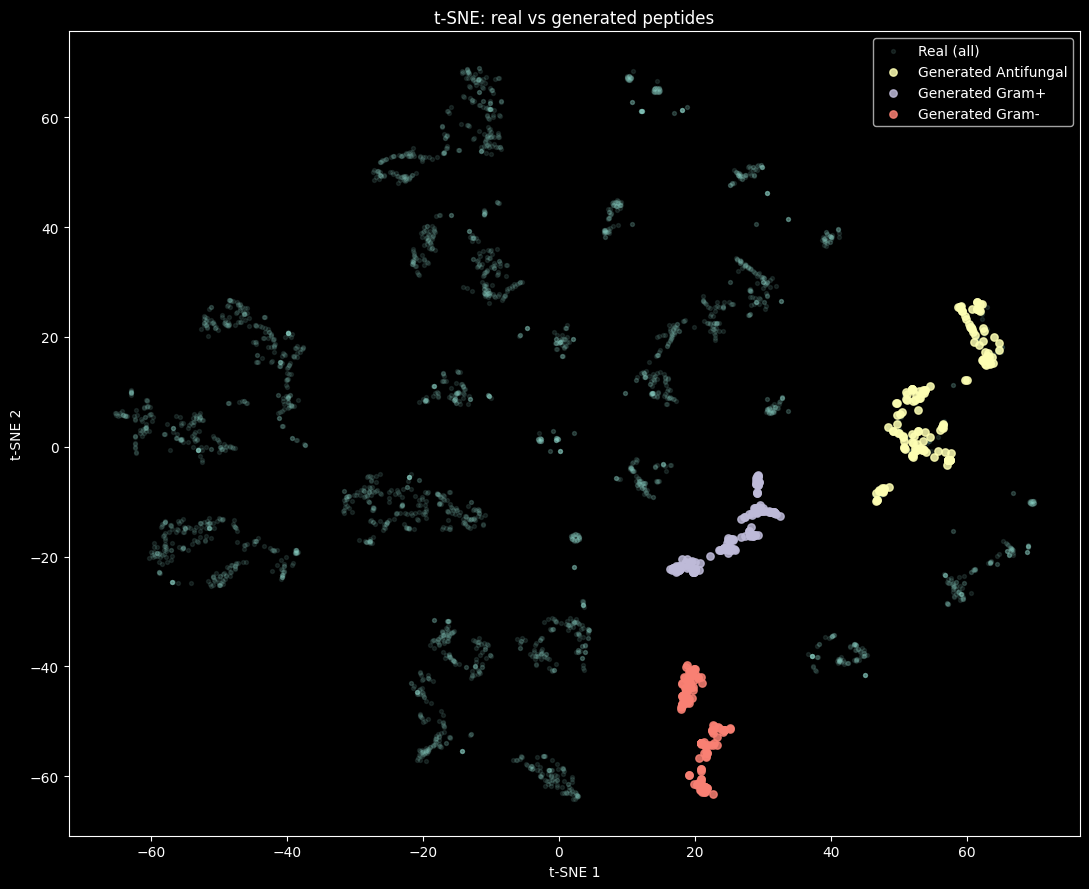

In [23]:
combined_latents = np.vstack([real_latents_sub, gen_latents])
combined_2d = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
).fit_transform(combined_latents)

real_2d_comb = combined_2d[: len(real_latents_sub)]
gen_2d_comb = combined_2d[len(real_latents_sub):]

fig, ax = plt.subplots(figsize=(11, 9))

ax.scatter(real_2d_comb[:, 0], real_2d_comb[:, 1], s=8, alpha=0.12, label="Real (all)")
for label in np.unique(gen_labels):
    idx = gen_labels == label
    ax.scatter(
        gen_2d_comb[idx, 0],
        gen_2d_comb[idx, 1],
        s=28,
        alpha=0.85,
        label=f"Generated {label}"
    )

ax.set_title("t-SNE: real vs generated peptides")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_real_vs_generated.png", dpi=220, bbox_inches="tight")
plt.show()


## 9. Color latent space by physicochemical properties


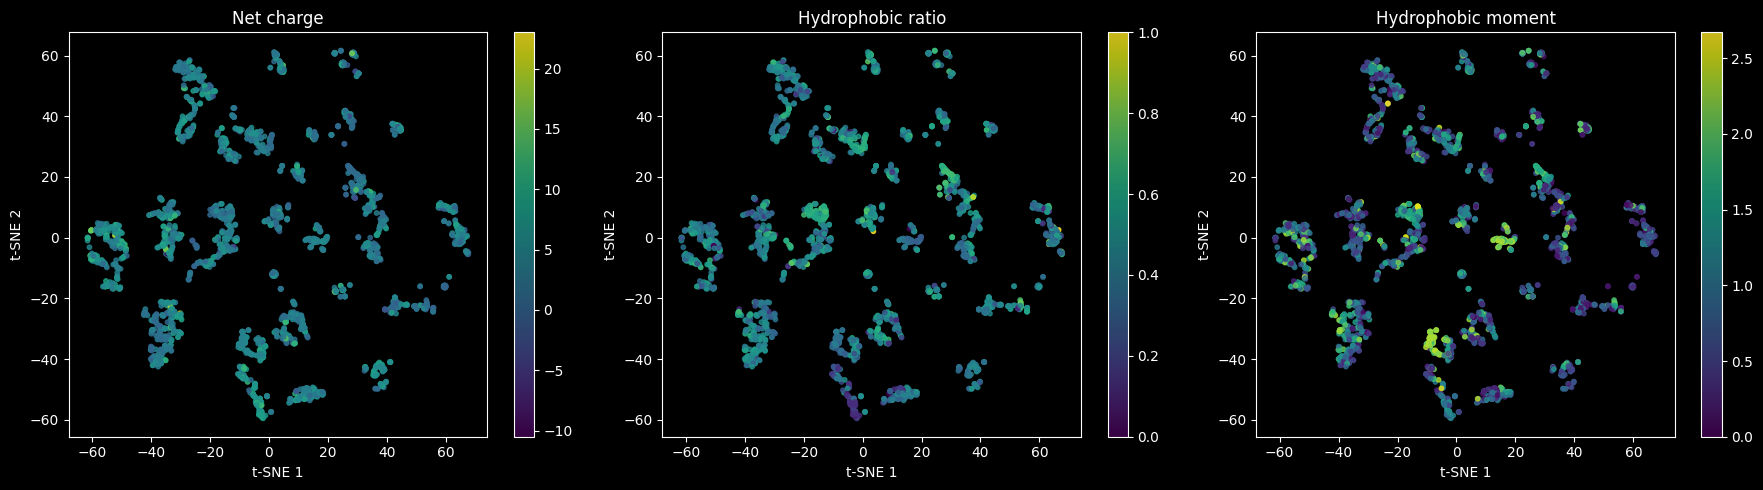

In [24]:
real_props_sub = compute_properties(real_df_sub[seq_col].tolist(), source_name="real_sub")
real_props_sub["tsne_1"] = real_2d[:, 0]
real_props_sub["tsne_2"] = real_2d[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
color_cols = [
    ("net_charge", "Net charge"),
    ("hydrophobic_ratio_apd", "Hydrophobic ratio"),
    ("hydrophobic_moment", "Hydrophobic moment"),
]

for ax, (col, title) in zip(axes, color_cols):
    sc = ax.scatter(
        real_props_sub["tsne_1"],
        real_props_sub["tsne_2"],
        c=real_props_sub[col],
        s=10,
        alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_colored_by_properties.png", dpi=220, bbox_inches="tight")
plt.show()


## 10. Example qualitative outputs


In [32]:
examples = []
for cond_name, cond_vec in {
    "Gram+": [0, 1, 0, 0, 0, 0, 0],
    "Gram-": [0, 0, 1, 0, 0, 0, 0],
    "Antifungal": [0, 0, 0, 1, 0, 0, 0],
}.items():
    for _ in range(5):
        seq = generate(model, cond_vec, temperature=0.8)
        examples.append({
            "condition": cond_name,
            "sequence": seq,
            "length": len(seq),
            "net_charge": net_charge(seq),
            "hydrophobic_ratio_apd": hydrophobic_ratio_apd(seq),
            "hydrophobic_moment": hydrophobic_moment(seq),
        })

examples_df = pd.DataFrame(examples)
examples_df.to_csv(TABLES_DIR / "generated_examples.csv", index=False)
examples_df


,condition,sequence,length,net_charge,hydrophobic_ratio_apd,hydrophobic_moment
0,Gram+,GLPVCGETCFGGTCNTPGCTCDPWPVCTRN,30,-1.0,0.366667,0.426515
1,Gram+,LTSILSLCTAGCITGKLQGCNNKTATCNCHV,31,2.5,0.451613,0.160223
2,Gram+,GLFLDTLKQAAKGAGQAVLNAVTGLVNEQV,30,0.0,0.500000,1.074468
3,Gram+,WNQSNI,6,0.0,0.333333,0.608009
4,Gram+,GLFLDTLKGAAKDLAGKLDKLIKCKIAGCKL,31,4.0,0.516129,1.079244
5,Gram-,RRIRPRPPRLPRPRPR,16,8.0,0.125000,1.226739
6,Gram-,GSKKPVPIIYCNRRTGKCQRM,21,6.0,0.285714,0.290607
7,Gram-,RRIRPRPPRLPRPRPR,16,8.0,0.125000,1.226739
8,Gram-,FWGRIWRSIRRG,12,4.0,0.416667,1.776735
9,Gram-,GFKKWFKKIEKMGQNIRDGVIKAGPAVGVLGQAKAL,36,6.0,0.444444,1.033282


## 11. Save summary artifacts


In [33]:
summary = {
    "reconstruction": recon_metrics,
    "generation_metrics_path": str(TABLES_DIR / "generation_metrics.csv"),
    "properties_path": str(TABLES_DIR / "peptide_properties.csv"),
    "examples_path": str(TABLES_DIR / "generated_examples.csv"),
}

with open(TABLES_DIR / "analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "reconstruction": {
    "exact_reconstruction_accuracy": 0.0,
    "token_accuracy": 0.5488149744142203,
    "n_sequences": 599
  },
  "generation_metrics_path": "C:\\Users\\artem\\Study\\explainable-VAE-for-AMP\\docs\\tables\\generation_metrics.csv",
  "properties_path": "C:\\Users\\artem\\Study\\explainable-VAE-for-AMP\\docs\\tables\\peptide_properties.csv",
  "examples_path": "C:\\Users\\artem\\Study\\explainable-VAE-for-AMP\\docs\\tables\\generated_examples.csv"
}


# results of cVAE analysis

The post-training analysis was run on the saved `best_cvae.pt` model using the APD6-based dataset with 5,984 sequences and a held-out test split of 599 peptides.

### Quantitative results
- Reconstruction on the test set is **moderate at token level** but **weak at exact-sequence level**:
  - exact reconstruction accuracy: **0.000**
  - token accuracy: **0.549**
- Generation quality is strong in terms of basic validity and novelty:
  - validity is **0.996-1.000** across tested conditions
  - uniqueness ranges from **0.804** to **1.000**
  - novelty ranges from **0.801** to **0.965**
- The best generation metrics were observed for **Antibacterial**, **Antifungal**, and **Unconditional** sampling.
- The weakest condition was **Gram-**, where uniqueness and novelty were noticeably lower than in other settings.

### Physicochemical analysis
- Generated peptides reproduce the **general range** of AMP properties, but the match to real peptides is only partial.
- **Gram+ generated peptides** are close to real Gram+ peptides in length and hydrophobic moment, but on average they have **lower net charge** than real Gram+ peptides.
- **Gram- generated peptides** are shorter and much more positively charged than real Gram- peptides, and they are also more hydrophilic on average.
- **Antifungal** and **Anticancer** generations tend to be **longer** than real peptides from the same groups and usually have **lower hydrophobic moment**.
- Overall, the model captures broad physicochemical trends, but condition-specific calibration is still imperfect.

### Latent space analysis
- t-SNE on real latent vectors shows that the latent space is **structured**, with visible grouping for **Gram+**, **Gram-**, and **Antifungal** peptides.
- Real-vs-generated comparison shows that generated peptides fall into **compact regions near the real latent manifold**, which means the generator is not producing completely random out-of-distribution sequences.
- At the same time, generated samples cover only a **limited part of the real latent diversity**, so diversity is still narrower than in the full dataset.
- Coloring the latent space by **net charge**, **hydrophobic ratio**, and **hydrophobic moment** shows that physicochemical properties vary smoothly in local neighborhoods, so the latent representation is biologically meaningful.

### Qualitative conclusion
The cVAE is able to generate valid and mostly novel AMP-like peptides and learns a meaningful latent organization. The strongest part of the model is **sampling quality**; the weaker part is **faithful reconstruction** and **fine-grained control of physicochemical properties**, especially for Gram- generation.